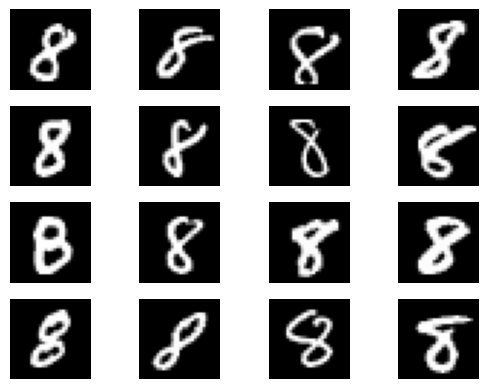

2025-12-11 15:48:18.341152: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-12-11 15:48:18.341169: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-11 15:48:18.341174: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-11 15:48:18.341189: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-11 15:48:18.341198: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
#导入所需要的模块与包
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from IPython import display

#导入 MNIST 数据集
mnist=tf.keras.datasets.mnist
(x_train,y_train),(__)=mnist.load_data()
#重构数据集并显示部分图像
x_train=x_train[y_train==8,]
for i in range(16):
    plt.subplot(4, 4, i+1)
    t=np.random.randint(1,x_train.shape[0])
    plt.axis("off")
    plt.imshow(x_train[t],cmap='gray')
plt.show()

#特征值标准化处理
x_train = x_train.reshape(x_train.shape[0],28,28,1).astype('float32')
x_train = (x_train-127.5)/127.5
#打乱数据并批量化
BUFFER_SIZE=6000
BATCH_SIZE=256
train_dataset=tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

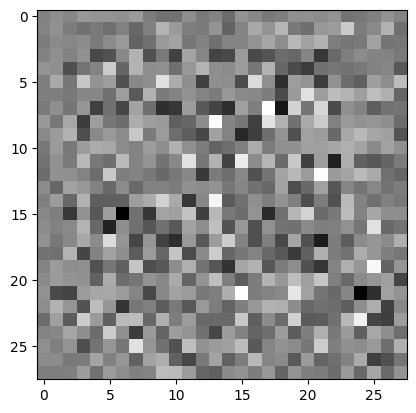

In [3]:
# 构建生成模型
def make_generator_model():
    model = tf.keras.Sequential() 
    
    model.add(tf.keras.layers.Dense(7*7*256,use_bias=False,input_shape=(100,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Reshape((7,7,256)))

    model.add(tf.keras.layers.Conv2DTranspose(128,(5,5),strides=(1,1),padding='same',use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    
    model.add(tf.keras.layers.Conv2DTranspose(64,(5,5),strides=(2,2),padding='same',use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    #为网络模型添加转置卷积层
    model.add(tf.keras.layers.Conv2DTranspose(1,(5,5),strides=(2,2),padding='same',use_bias=False,activation='tanh'))
    return model

generator=make_generator_model()    # 创建生成模型
generator.summary() 
#创建生成样本测试
noise=tf.random.normal([1,100])    # 输入噪声

generated_image=generator(noise,training=False)

plt.imshow(generated_image[0,:,:,0], cmap='gray')

In [5]:
#构建判别模型
def make_discriminator_model(): 
    model=tf.keras.Sequential() 

    model.add(tf.keras.layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=[28,28,1]))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))
    
    model.add(tf.keras.layers.Flatten()) 
    model.add(tf.keras.layers.Dense(1)) 
    
    return model

discriminator=make_discriminator_model() 

discriminator.summary()
# 调用
decision=discriminator(generated_image) 
print(decision) 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

tf.Tensor([[0.00031307]], shape=(1, 1), dtype=float32)


In [6]:
# 定义损失函数和优化器
cross_entropy=tf.keras.losses.BinaryCrossentropy(from_logits=True)

# 定义判别模型的损失函数
def discriminator_loss(real_output,fake_output):
    real_loss=cross_entropy(tf.ones_like(real_output),real_output)
    fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
    total_loss=real_loss+fake_loss
    return total_loss
# 生成模型的损失函数
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output),fake_output)

    
# 生成模型的优化器
generator_optimizer=tf.keras.optimizers.Adam(1e-4)
# 判别模型的优化器
discriminator_optimizer=tf.keras.optimizers.Adam(1e-4)

In [7]:
#定义检查点
checkpoint_dir='./MLex14Checkpoints' 

#定义检查点的文件名
checkpoint_prefix=os.path.join(checkpoint_dir,"ml14ckpt")

#定义检查点对象
checkpoint=tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                               discriminator_optimizer=discriminator_optimizer,
                               generator=generator,
                               discriminator=discriminator)

<Figure size 640x480 with 0 Axes>

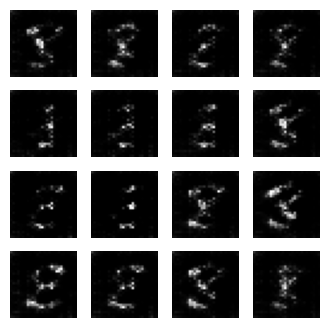

第20次，花费6.062788963317871秒


<Figure size 640x480 with 0 Axes>

In [8]:
# 定义训练模型的参数
EPOCHS=20
noise_dim=100
num_examples_to_generate=16 

# 产生随机种子作为输入向量
seed = tf.random.normal([num_examples_to_generate, noise_dim])

# 定义单次训练模型函数
def train_step(images):
    # 随机函数生成输入噪声
    noise=tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 使用生成模型创建生成样本
        generated_images=generator(noise,training=True)
        # 对真实样本判别
        real_output = discriminator(images, training=True)
        # 对生成样本进行判别
        fake_output=discriminator(generated_images, training=True)
        # 生成模型损失值
        gen_loss=generator_loss(fake_output)
        # 判别模型损失值
        disc_loss=discriminator_loss(real_output,fake_output)
    # 梯度
    gradients_of_generator=gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator=disc_tape.gradient(disc_loss,discriminator.trainable_variables)
    # 更新参数
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,discriminator.trainable_variables))

# 可视化
def generate_and_save_images(model, epoch, test_input):
    # 产生生成样本
    predictions=model(test_input, training=False)
    # 显示生成样本
    fig=plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4,4, i+1)
        plt.imshow(predictions[i,:,:,0]*127.5+127.5, cmap="gray")
        plt.axis('off')
    plt.show()
    # 保存生成样本
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    
# 完整训练模型函数
def train(dataset,epochs):
    for epoch in range(epochs):
        start = time.time()    #开始训练时间
        for image_batch in dataset:    #逐批次训练
            train_step(image_batch)
        display.clear_output(wait=True)
        generate_and_save_images(generator,epoch+1,seed)
        # 每训练10次保存一次检查点
        if(epoch+1)%10==0:
            checkpoint.save(file_prefix = checkpoint_prefix)
        
        print('第{}次，花费{}秒'.format(epoch+1, time.time()-start))
train(train_dataset,EPOCHS) 